# 01 — Exploratory Data Analysis (EDA)

**Nguồn dữ liệu**: MySQL → bảng `cleaned_cars` (đã load bởi ETL pipeline)

**Mục tiêu**:
- Kết nối DB, SELECT toàn bộ dữ liệu đã clean
- Phân tích phân phối giá, km, năm sản xuất
- Vẽ biểu đồ theo từng đặc trưng phân loại
- Tìm tương quan giữa các biến số

> ⚠️ **Yêu cầu**: Đã chạy `python -m src.etl_pipeline` để load data vào DB trước.

## 0. Import & Cấu hình

In [1]:
import sys
from pathlib import Path

# Thêm thư mục gốc project vào sys.path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Thư mục lưu hình ảnh output
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from src.db_connector import DBConnector
from src.business_insights import (
    standardize_car_columns, compute_depreciation, plot_depreciation,
    compute_mileage_penalty, plot_mileage_penalty,
    compute_feature_premium, plot_feature_premium,
)

warnings.filterwarnings('ignore')

# Style toàn cục
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'font.family': 'DejaVu Sans',
})

print(f'✓ Import thành công')
print(f'✓ Output dir: {OUTPUT_DIR}')

✓ Import thành công
✓ Output dir: /Users/macbook/Documents/Car_Data_Analysis/output


## 1. Kết nối Database & Load dữ liệu

In [2]:
# Ưu tiên đọc từ MySQL; nếu môi trường chưa mở DB thì dùng CSV backup đã clean.
db = None
conn = None
try:
    db = DBConnector()
    conn = db.get_connection()
    df = pd.read_sql("""
        SELECT 
            id, ten_xe, gia, so_ghe, nam_sx,
            nhien_lieu, kieu_dang, tinh_trang,
            km_da_di, hop_so, xuat_xu, tinh_thanh,
            log_gia, log_km
        FROM cleaned_cars
        ORDER BY id
    """, conn)
    data_source = 'MySQL: cleaned_cars'
except Exception as exc:
    print(f'Không kết nối được MySQL, chuyển sang CSV backup: {exc}')
    csv_path = ROOT / 'data' / 'processed' / 'car_data_cleaned.csv'
    df = pd.read_csv(csv_path)
    data_source = f'CSV backup: {csv_path.name}'

# Chuẩn hóa tên cột và bổ sung brand/model_line/age/price_band cho phân tích kinh doanh.
df = standardize_car_columns(df)

print(f'Nguồn dữ liệu: {data_source}')
print(f'Shape: {df.shape}')
df.head()

[DB] Kết nối thành công → MySQL Server 9.1.0 | DB: car_analytics
Nguồn dữ liệu: MySQL: cleaned_cars
Shape: (2958, 20)


,id,ten_xe,gia,so_ghe,nam_sx,nhien_lieu,kieu_dang,tinh_trang,km_da_di,hop_so,xuat_xu,tinh_thanh,log_gia,log_km,brand,model_line,brand_group,age,gia_trieu,price_band
0,1,Hyundai Kona 2.0 AT Đặc biệt 2019,450000000,5,2019,Máy xăng,SUV,Xe cũ,80000.0,Số tự động,Trong nước,Nam Từ Liêm - Hà Nội,19.9248,11.28980,Hyundai,Hyundai Kona,Hàn,6,450.0,300-500tr
1,2,Ford Everest Titanium 2.0 AT 4x2 2023,1225000000,7,2023,Máy dầu,SUV,Xe cũ,22000.0,Số tự động,Nhập khẩu,Hoàng Mai - Hà Nội,20.9262,9.99884,Ford,Ford Everest,Mỹ,2,1225.0,1-1.5ty
2,3,Ford Transit 2022,715000000,16,2022,Máy dầu,Van/Minivan,Xe cũ,40000.0,Số sàn,Trong nước,Tân Phú - Tp.HCM,20.3878,10.59670,Ford,Ford Transit,Mỹ,3,715.0,700tr-1ty
3,4,Mazda 3 Sedan 1.5L Luxury 2020,499000000,5,2020,Máy xăng,Sedan,Xe cũ,3200.0,Số tự động,Trong nước,Hoàng Mai - Hà Nội,20.0281,8.07122,Mazda,Mazda 3,Nhật,5,499.0,300-500tr
4,5,Mitsubishi Xpander 1.5 MT 2019,420000000,7,2019,Máy xăng,MPV,Xe cũ,76000.0,Số tự động,Nhập khẩu,Thuận An - Bình Dương,19.8558,11.23850,Mitsubishi,Mitsubishi Xpander,Nhật,6,420.0,300-500tr


In [3]:
# Tổng quan dữ liệu
print('=== Thông tin cột ===')
df.info()
print('\n=== Thống kê mô tả (số) ===')
df.describe()

=== Thông tin cột ===
<class 'pandas.DataFrame'>
RangeIndex: 2958 entries, 0 to 2957
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           2958 non-null   int64   
 1   ten_xe       2958 non-null   str     
 2   gia          2958 non-null   int64   
 3   so_ghe       2958 non-null   int64   
 4   nam_sx       2958 non-null   int64   
 5   nhien_lieu   2958 non-null   str     
 6   kieu_dang    2958 non-null   str     
 7   tinh_trang   2958 non-null   str     
 8   km_da_di     2958 non-null   float64 
 9   hop_so       2958 non-null   str     
 10  xuat_xu      2958 non-null   str     
 11  tinh_thanh   2958 non-null   str     
 12  log_gia      2958 non-null   float64 
 13  log_km       2958 non-null   float64 
 14  brand        2958 non-null   str     
 15  model_line   2958 non-null   str     
 16  brand_group  2958 non-null   str     
 17  age          2958 non-null   int64   
 18  gia_trieu    2958

,id,gia,so_ghe,nam_sx,km_da_di,log_gia,log_km,age,gia_trieu
count,2958.000000,2.958000e+03,2958.000000,2958.000000,2958.000000,2958.000000,2958.000000,2958.000000,2958.000000
mean,1479.500000,1.197144e+09,4.865788,2021.720081,35487.861055,20.438004,5.258386,3.279919,1197.143819
std,854.045374,1.777771e+09,2.228548,4.448261,65856.337776,0.862961,5.408257,4.448261,1777.770656
min,1.000000,2.500000e+07,0.000000,2001.000000,0.000000,17.034400,0.000000,0.000000,25.000000
25%,740.250000,4.500000e+08,5.000000,2020.000000,0.000000,19.924800,0.000000,0.000000,450.000000
50%,1479.500000,6.590000e+08,5.000000,2024.000000,0.000000,20.306200,0.000000,1.000000,659.000000
75%,2218.750000,1.099000e+09,5.000000,2025.000000,60000.000000,20.817700,11.002100,5.000000,1099.000000
max,2958.000000,2.678900e+10,29.000000,2025.000000,970000.000000,24.011300,13.785100,24.000000,26789.000000


In [4]:
# Kiểm tra giá trị thiếu
null_counts = df.isnull().sum()
print('Giá trị NaN còn lại trong DB:')
print(null_counts[null_counts > 0] if null_counts.any() else '✓ Không có NaN')

Giá trị NaN còn lại trong DB:
✓ Không có NaN


## 2. Phân phối Giá xe

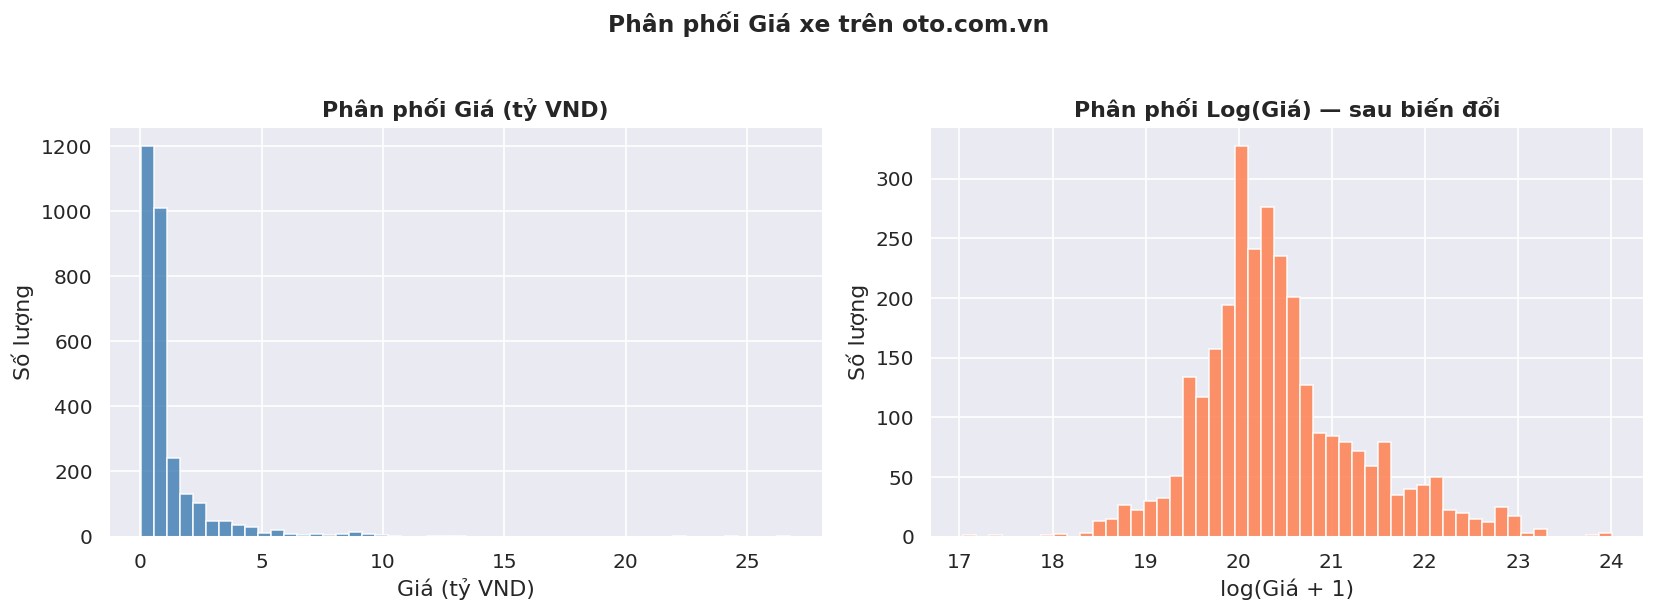

✓ Đã lưu → output/eda_01_price_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối giá gốc
axes[0].hist(df['gia'] / 1e9, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Phân phối Giá (tỷ VND)', fontweight='bold')
axes[0].set_xlabel('Giá (tỷ VND)')
axes[0].set_ylabel('Số lượng')

# Phân phối log(giá)
axes[1].hist(df['log_gia'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Phân phối Log(Giá) — sau biến đổi', fontweight='bold')
axes[1].set_xlabel('log(Giá + 1)')
axes[1].set_ylabel('Số lượng')

plt.suptitle('Phân phối Giá xe trên oto.com.vn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_01_price_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/eda_01_price_distribution.png')

## 3. Phân tích theo Tình trạng (Xe cũ / Xe mới)

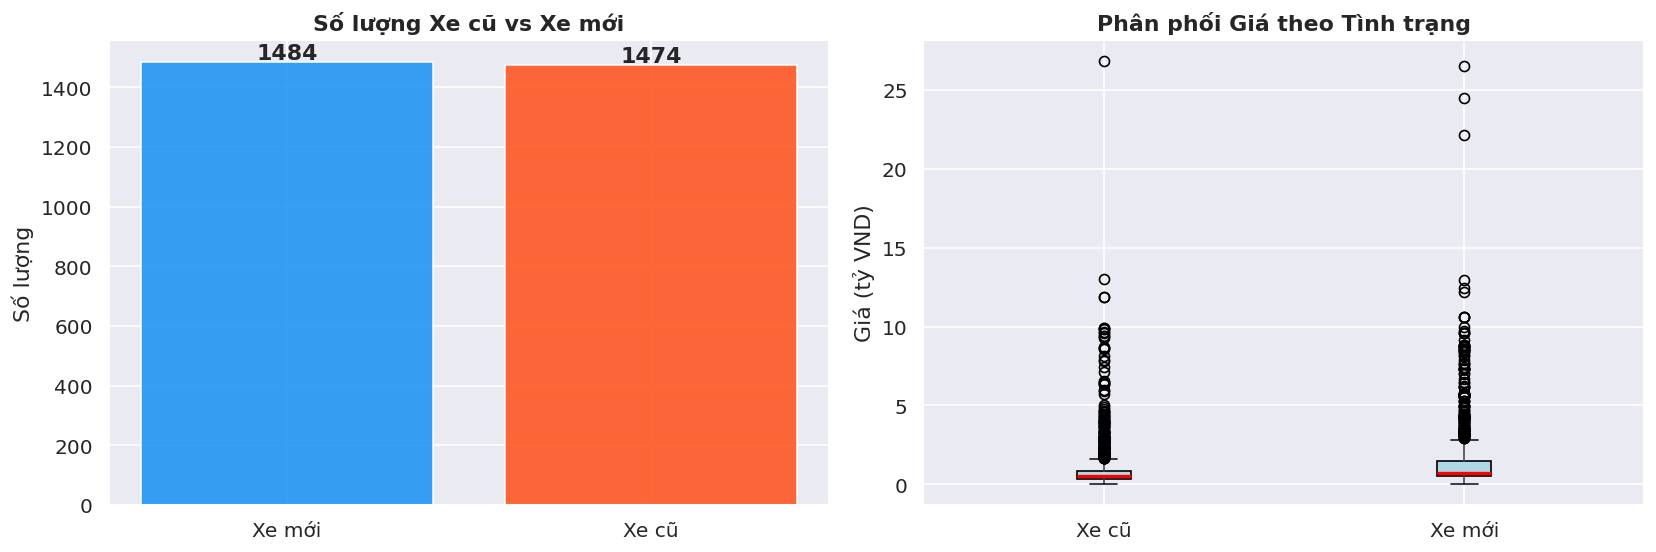

✓ Đã lưu → output/eda_02_status_price.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đếm số lượng
status_counts = df['tinh_trang'].value_counts()
axes[0].bar(status_counts.index, status_counts.values,
            color=['#2196F3', '#FF5722'], edgecolor='white', alpha=0.9)
axes[0].set_title('Số lượng Xe cũ vs Xe mới', fontweight='bold')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Boxplot giá theo tình trạng
df_plot = df.copy()
df_plot['gia_ty'] = df_plot['gia'] / 1e9
df_plot.boxplot(column='gia_ty', by='tinh_trang', ax=axes[1],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Phân phối Giá theo Tình trạng', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Giá (tỷ VND)')
plt.suptitle('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_02_status_price.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/eda_02_status_price.png')

## 4. Xuất xứ & Kiểu dáng

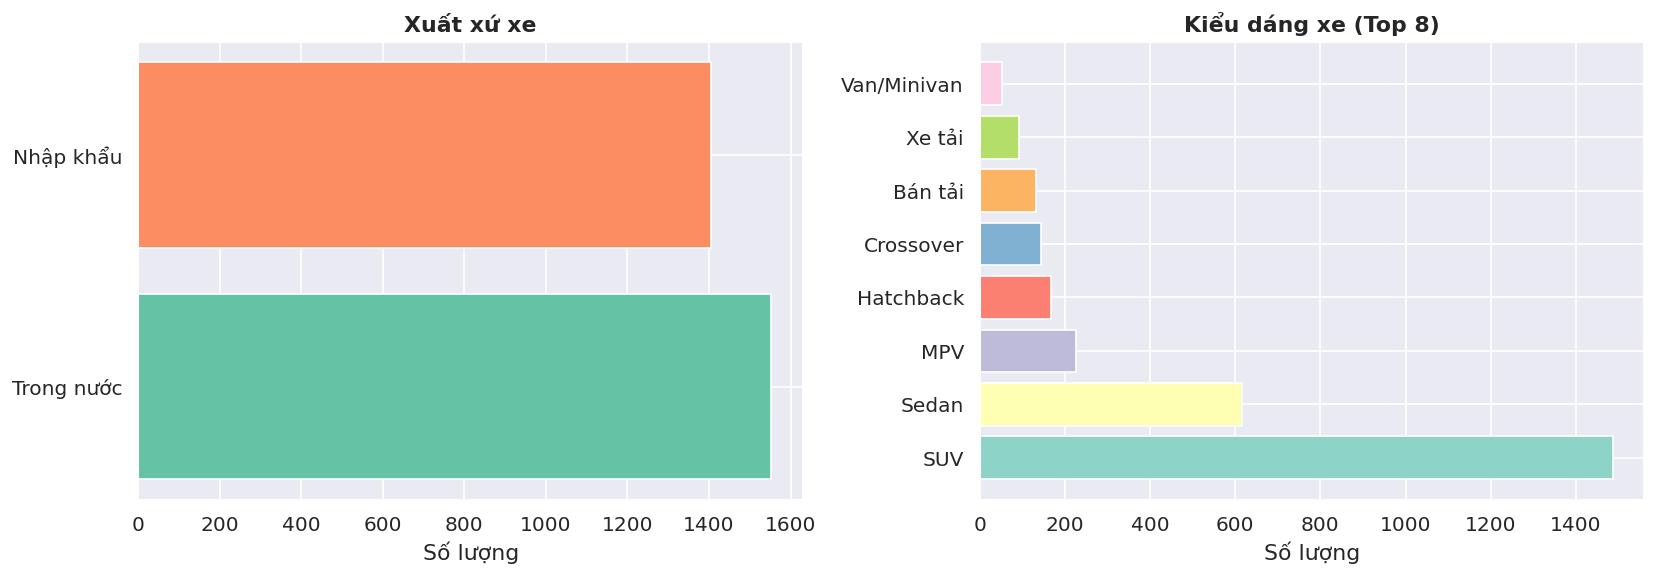

✓ Đã lưu → output/eda_03_origin_style.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Xuất xứ
origin_counts = df['xuat_xu'].value_counts()
axes[0].barh(origin_counts.index, origin_counts.values,
             color=sns.color_palette('Set2', len(origin_counts)))
axes[0].set_title('Xuất xứ xe', fontweight='bold')
axes[0].set_xlabel('Số lượng')

# Kiểu dáng
style_counts = df['kieu_dang'].value_counts().head(8)
axes[1].barh(style_counts.index, style_counts.values,
             color=sns.color_palette('Set3', len(style_counts)))
axes[1].set_title('Kiểu dáng xe (Top 8)', fontweight='bold')
axes[1].set_xlabel('Số lượng')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_03_origin_style.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/eda_03_origin_style.png')

## 5. Ma trận tương quan

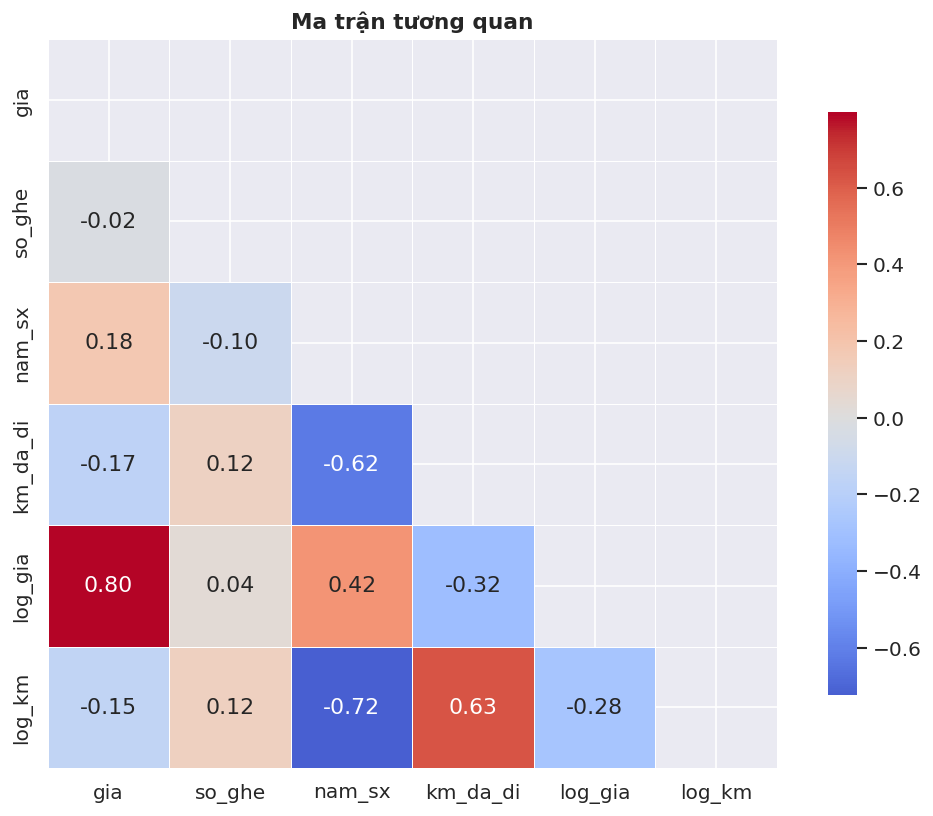

✓ Đã lưu → output/eda_04_correlation_heatmap.png


In [8]:
num_cols = ['gia', 'so_ghe', 'nam_sx', 'km_da_di', 'log_gia', 'log_km']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Ma trận tương quan', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_04_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/eda_04_correlation_heatmap.png')

## 6. Giá vs Năm sản xuất & Km đã đi

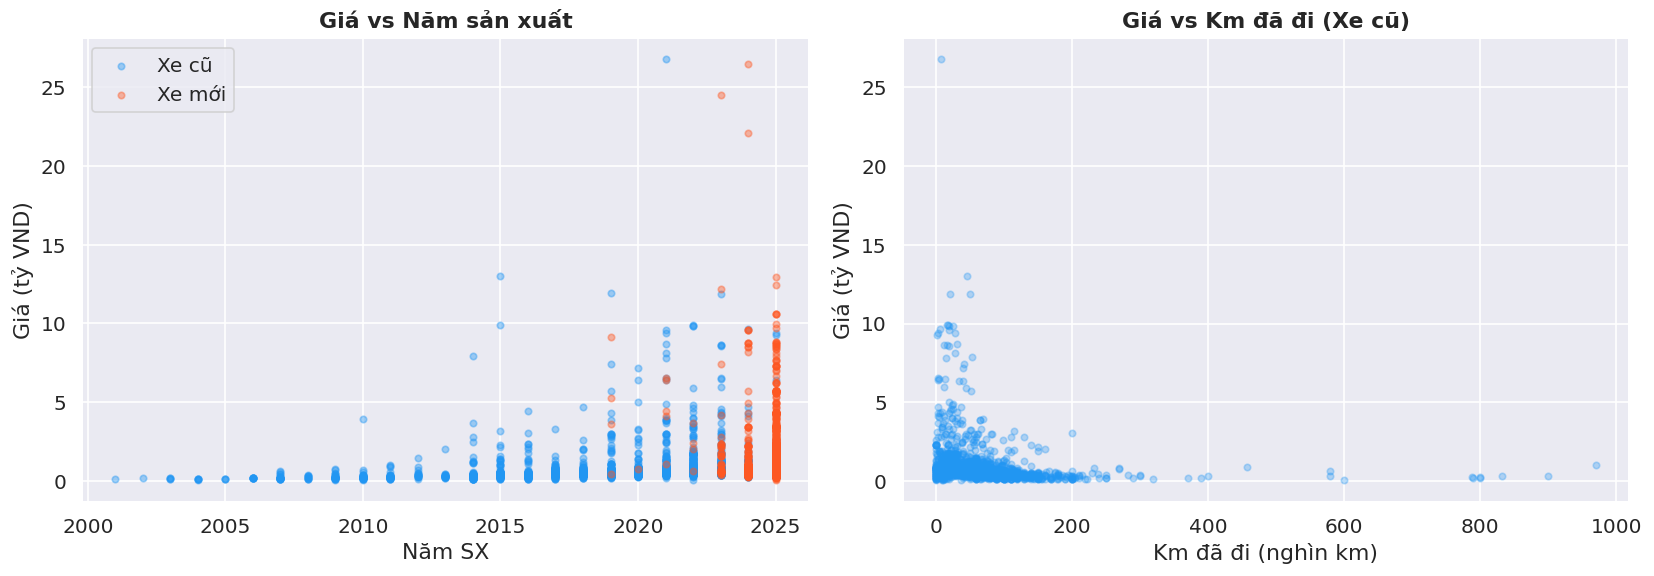

✓ Đã lưu → output/eda_05_price_vs_features.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_map = {'Xe cũ': '#2196F3', 'Xe mới': '#FF5722'}

for status, grp in df.groupby('tinh_trang'):
    axes[0].scatter(grp['nam_sx'], grp['gia'] / 1e9,
                    label=status, alpha=0.4, s=15,
                    color=color_map.get(status, 'gray'))

axes[0].set_title('Giá vs Năm sản xuất', fontweight='bold')
axes[0].set_xlabel('Năm SX')
axes[0].set_ylabel('Giá (tỷ VND)')
axes[0].legend()

for status, grp in df[df['tinh_trang'] == 'Xe cũ'].groupby('tinh_trang'):
    axes[1].scatter(grp['km_da_di'] / 1000, grp['gia'] / 1e9,
                    alpha=0.3, s=15, color='#2196F3', label='Xe cũ')

axes[1].set_title('Giá vs Km đã đi (Xe cũ)', fontweight='bold')
axes[1].set_xlabel('Km đã đi (nghìn km)')
axes[1].set_ylabel('Giá (tỷ VND)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_05_price_vs_features.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/eda_05_price_vs_features.png')

## 7. Violin Plot: Giá theo Kiểu dáng

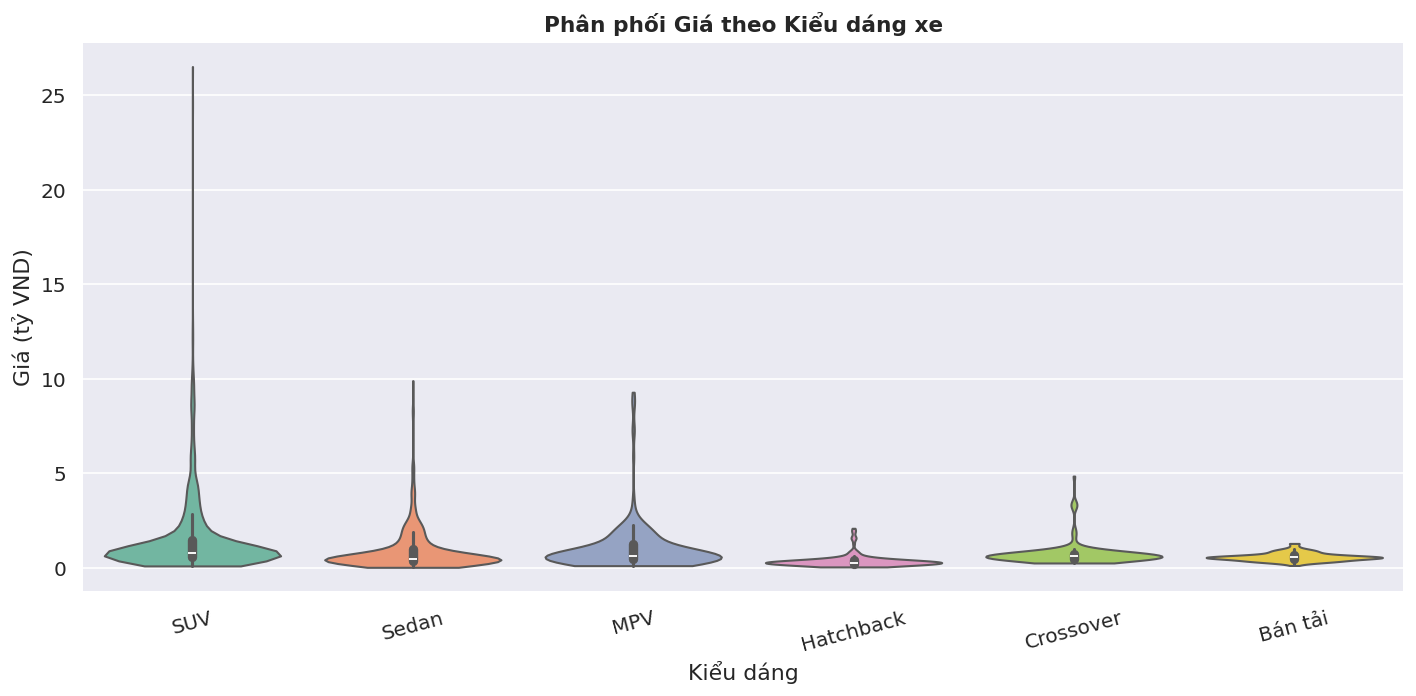

✓ Đã lưu → output/eda_06_violin_style.png


In [10]:
# Chỉ lấy top kiểu dáng để biểu đồ rõ hơn
top_styles = df['kieu_dang'].value_counts().head(6).index
df_violin = df[df['kieu_dang'].isin(top_styles)].copy()
df_violin['gia_ty'] = df_violin['gia'] / 1e9

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_violin, x='kieu_dang', y='gia_ty',
    palette='Set2', inner='box', cut=0
)
plt.title('Phân phối Giá theo Kiểu dáng xe', fontweight='bold', fontsize=13)
plt.xlabel('Kiểu dáng')
plt.ylabel('Giá (tỷ VND)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_06_violin_style.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/eda_06_violin_style.png')

## 8. Business Insight: Tốc độ khấu hao (Depreciation Curve)

Mục tiêu kinh doanh: nhận diện dòng xe/nhóm hãng/hãng xe rớt giá nhanh để tránh ôm hàng tồn và ưu tiên nguồn vốn cho xe giữ giá tốt.

Lưu ý phương pháp: đường cong và hệ số khấu hao chỉ dùng các mốc tuổi có ít nhất 2 tin đăng để giảm nhiễu do mẫu đơn lẻ hoặc khác phiên bản như C200/C300/C63.

=== Top dòng xe khấu hao nhanh nhất ===


,model_line,n,so_nam,annual_depreciation_pct,median_price_million,min_age,max_age
13,Mercedes-Benz C300,21,9,13.2,1469.0,0,10
15,Mercedes-Benz GLC,54,9,13.2,1358.0,0,9
12,Mercedes-Benz C200,20,9,11.8,814.0,2,14
14,Mercedes-Benz E,20,9,11.1,1315.0,2,15
6,Hyundai Santa Fe,28,12,10.1,860.0,1,18
5,Hyundai Grand i10,45,12,10.1,235.0,1,15
7,Hyundai Tucson,18,9,9.5,662.0,0,16
17,Toyota Camry,26,13,9.5,767.0,1,18
3,Honda CR-V,28,11,9.0,695.0,2,15
1,Ford Everest,34,13,8.7,1027.0,0,18


=== Khấu hao theo nhóm hãng ===


,brand_group,n,so_moc_tuoi,annual_depreciation_pct,median_price_million
1,Mỹ,198,18,12.6,482.0
4,Âu,279,20,11.2,1390.0
0,Hàn,304,19,7.9,436.0
2,Nhật,558,21,4.9,490.0
3,Việt,73,8,4.1,600.0


=== Khấu hao theo từng hãng ===


,brand,brand_group,n,so_moc_tuoi,annual_depreciation_pct,median_price_million
0,BMW,Âu,37,14,14.5,1399.0
4,Kia,Hàn,133,18,12.2,438.0
1,Ford,Mỹ,172,18,10.9,535.0
7,Mercedes-Benz,Âu,163,18,10.8,1299.0
3,Hyundai,Hàn,171,18,8.7,435.0
6,Mazda,Nhật,97,13,7.2,470.0
9,Toyota,Nhật,249,20,6.7,468.0
8,Mitsubishi,Nhật,65,13,6.4,486.0
5,Lexus,Nhật,45,14,5.7,2899.0
2,Honda,Nhật,57,15,5.5,495.0


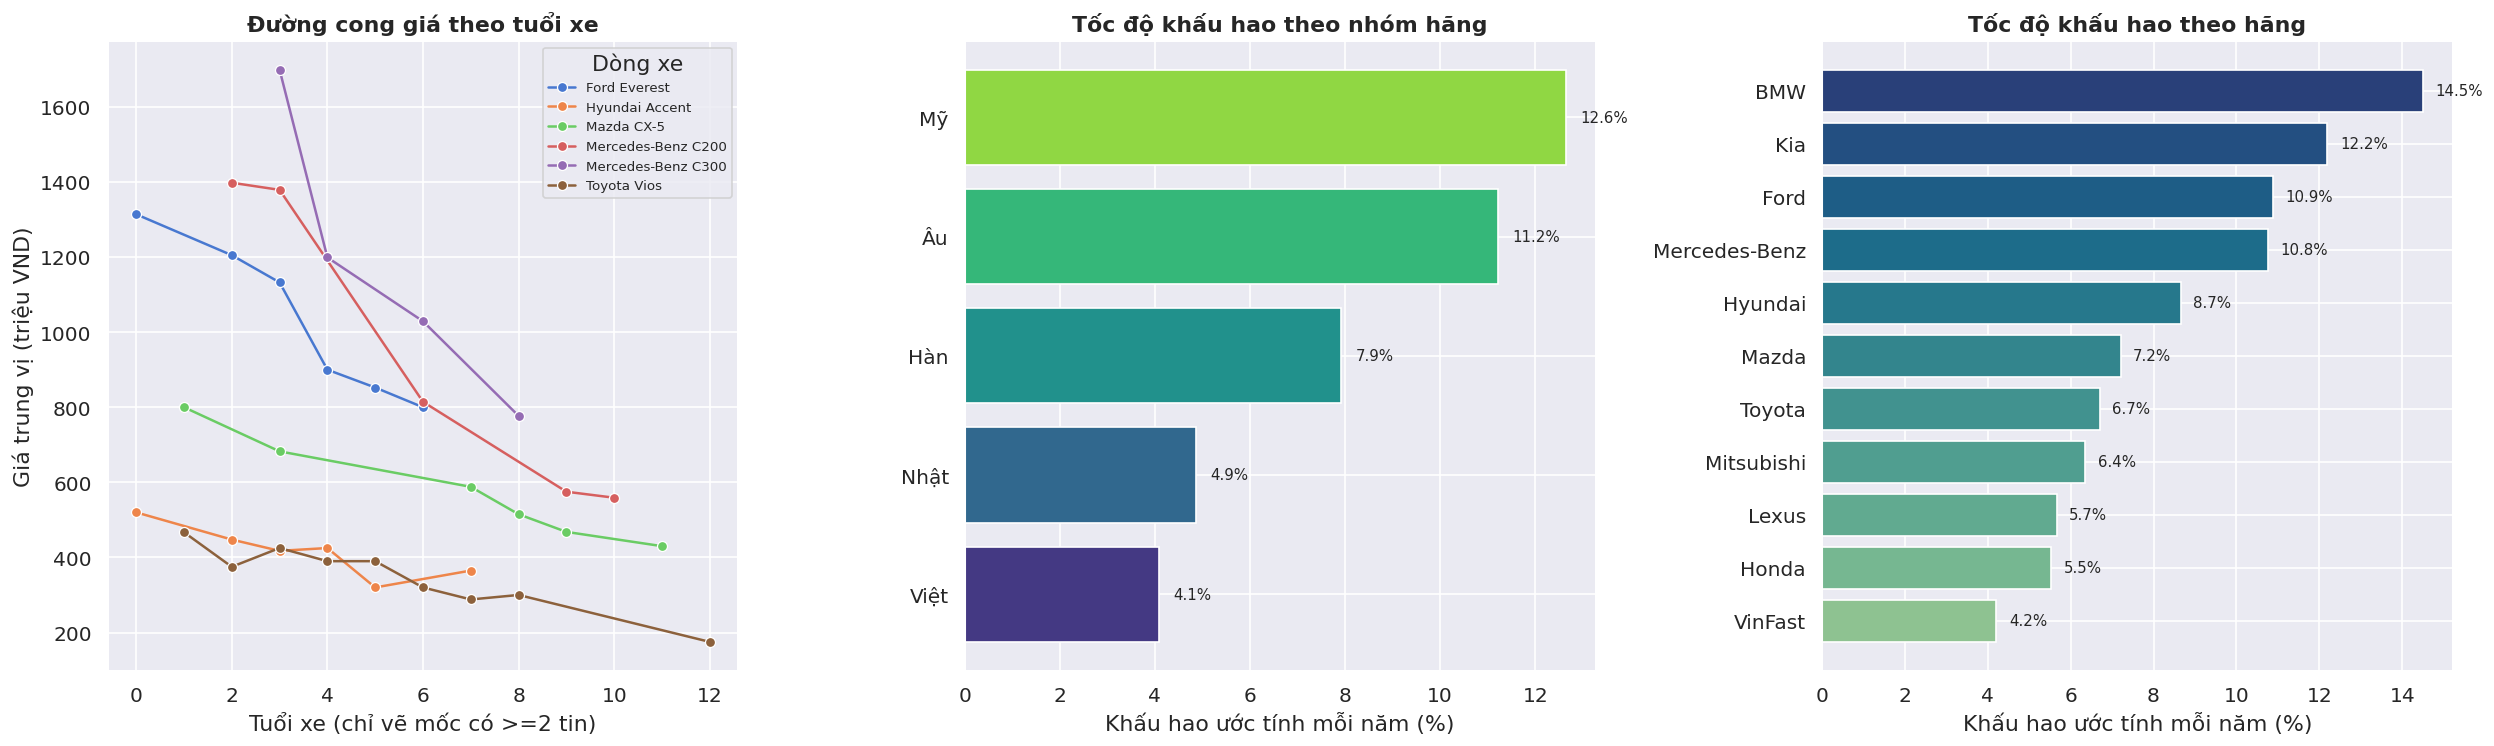

Insight: nhóm Mỹ đang khấu hao nhanh nhất (~12.6%/năm), trong khi nhóm Việt giữ giá tốt hơn (~4.1%/năm).
Theo từng hãng, BMW khấu hao nhanh nhất (~14.5%/năm), còn VinFast giữ giá tốt hơn trong các hãng đủ mẫu (~4.2%/năm).
Khuyến nghị thu mua: cẩn trọng với Mercedes-Benz C300 (~13.2%/năm); ưu tiên kiểm tra nguồn hàng Toyota Corolla Cross vì tốc độ rớt giá thấp hơn (~5.6%/năm).
✓ Đã lưu → output/business_01_depreciation_curve.png


In [11]:
dep_models, dep_groups, dep_brands, dep_curves = compute_depreciation(df)

print('=== Top dòng xe khấu hao nhanh nhất ===')
display(dep_models.head(10).round({
    'annual_depreciation_pct': 1,
    'median_price_million': 0,
}))

print('=== Khấu hao theo nhóm hãng ===')
display(dep_groups.round({
    'annual_depreciation_pct': 1,
    'median_price_million': 0,
}))

print('=== Khấu hao theo từng hãng ===')
display(dep_brands.head(12).round({
    'annual_depreciation_pct': 1,
    'median_price_million': 0,
}))

plot_depreciation(
    dep_models,
    dep_groups,
    dep_brands,
    dep_curves,
    OUTPUT_DIR / 'business_01_depreciation_curve.png',
)

fastest = dep_models.iloc[0]
slowest = dep_models.sort_values('annual_depreciation_pct').iloc[0]
if not dep_groups.empty:
    best_group = dep_groups.sort_values('annual_depreciation_pct').iloc[0]
    worst_group = dep_groups.iloc[0]
    print(
        f"Insight: nhóm {worst_group['brand_group']} đang khấu hao nhanh nhất "
        f"(~{worst_group['annual_depreciation_pct']:.1f}%/năm), trong khi nhóm "
        f"{best_group['brand_group']} giữ giá tốt hơn (~{best_group['annual_depreciation_pct']:.1f}%/năm)."
    )
if not dep_brands.empty:
    worst_brand = dep_brands.iloc[0]
    best_brand = dep_brands.sort_values('annual_depreciation_pct').iloc[0]
    print(
        f"Theo từng hãng, {worst_brand['brand']} khấu hao nhanh nhất "
        f"(~{worst_brand['annual_depreciation_pct']:.1f}%/năm), còn {best_brand['brand']} "
        f"giữ giá tốt hơn trong các hãng đủ mẫu (~{best_brand['annual_depreciation_pct']:.1f}%/năm)."
    )
print(
    f"Khuyến nghị thu mua: cẩn trọng với {fastest['model_line']} "
    f"(~{fastest['annual_depreciation_pct']:.1f}%/năm); ưu tiên kiểm tra nguồn hàng "
    f"{slowest['model_line']} vì tốc độ rớt giá thấp hơn "
    f"(~{slowest['annual_depreciation_pct']:.1f}%/năm)."
)
print('✓ Đã lưu → output/business_01_depreciation_curve.png')

## 9. Business Insight: Định giá độ hao mòn (Mileage Penalty)

Mục tiêu kinh doanh: biến ODO thành một hệ số phạt giá có thể đưa vào barem định giá thu mua.

,Số xe dùng để fit,Corr thô Km-Giá,R2 mô hình,Phạt mỗi 10.000 km (triệu),Phạt mỗi năm tuổi xe (triệu)
0,1422,-0.293,0.874,8.028,73.641


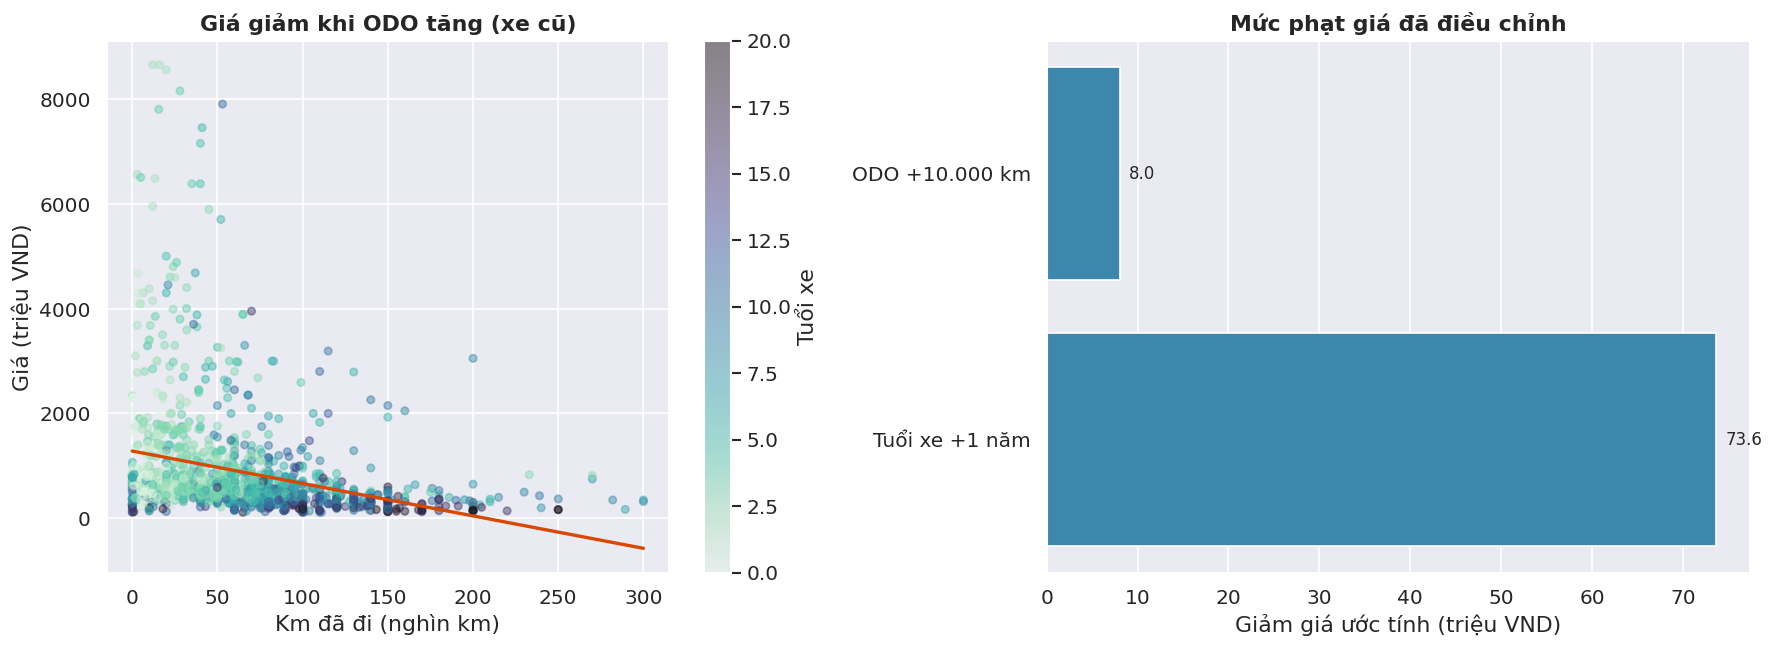

Insight: tương quan thô giữa ODO và giá là -0.29. Sau khi kiểm soát dòng xe, tuổi xe, kiểu dáng, xuất xứ, hộp số và nhiên liệu, mỗi 10.000 km làm giảm khoảng 8.0 triệu VND.
Ứng dụng: lấy giá trần của dòng xe/đời xe làm base price, sau đó trừ hệ số ODO để tạo giá thu mua khởi điểm cho sale.
✓ Đã lưu → output/business_02_mileage_penalty.png


In [12]:
mileage_summary, mileage_data = compute_mileage_penalty(df)

summary_display = pd.DataFrame([{
    'Số xe dùng để fit': mileage_summary['n'],
    'Corr thô Km-Giá': mileage_summary['raw_corr_km_price'],
    'R2 mô hình': mileage_summary['r2'],
    'Phạt mỗi 10.000 km (triệu)': mileage_summary['penalty_million_per_10k'],
    'Phạt mỗi năm tuổi xe (triệu)': mileage_summary['penalty_million_per_year_age'],
}])
display(summary_display.round(3))

plot_mileage_penalty(
    mileage_data,
    mileage_summary,
    OUTPUT_DIR / 'business_02_mileage_penalty.png',
)

print(
    f"Insight: tương quan thô giữa ODO và giá là {mileage_summary['raw_corr_km_price']:.2f}. "
    f"Sau khi kiểm soát dòng xe, tuổi xe, kiểu dáng, xuất xứ, hộp số và nhiên liệu, "
    f"mỗi 10.000 km làm giảm khoảng {mileage_summary['penalty_million_per_10k']:.1f} triệu VND."
)
print(
    'Ứng dụng: lấy giá trần của dòng xe/đời xe làm base price, sau đó trừ hệ số ODO '
    'để tạo giá thu mua khởi điểm cho sale.'
)
print('✓ Đã lưu → output/business_02_mileage_penalty.png')

## 10. Business Insight: Feature Premium Analysis

Mục tiêu kinh doanh: định lượng khách hàng đang trả thêm bao nhiêu cho xe nhập khẩu hoặc số tự động khi so trong cùng dòng xe và cùng năm sản xuất.

=== Cặp so sánh xuất xứ có nhiều mẫu nhất ===


,model_line,nam_sx,n,premium_pct,premium_price_million,base_price_million,premium_value,base_value
19,MG 5,2024,32,-6.7,432.0,464.0,Nhập khẩu,Trong nước
12,Ford Ranger,2025,21,61.1,1139.0,707.0,Nhập khẩu,Trong nước
35,Mitsubishi Xpander,2025,15,12.3,618.0,550.0,Nhập khẩu,Trong nước
43,Toyota Corolla Cross,2025,14,6.5,820.0,770.0,Nhập khẩu,Trong nước
21,Mazda 2,2025,13,0.0,402.0,402.0,Nhập khẩu,Trong nước
20,MG G50,2025,12,-14.5,559.0,654.0,Nhập khẩu,Trong nước
30,Mercedes-Benz GLC,2022,12,-0.3,1474.0,1479.0,Nhập khẩu,Trong nước
13,Ford Territory,2025,11,-5.3,720.0,760.0,Nhập khẩu,Trong nước
51,Toyota Veloz,2025,10,12.8,660.0,585.0,Nhập khẩu,Trong nước
14,Honda CR-V,2024,10,24.5,1209.0,971.0,Nhập khẩu,Trong nước


=== Cặp so sánh hộp số có nhiều mẫu nhất ===


,model_line,nam_sx,n,premium_pct,premium_price_million,base_price_million,premium_value,base_value
13,MG 5,2024,32,43.4,468.0,326.0,Số tự động,Số sàn
15,MG G50,2025,12,8.0,604.0,559.0,Số tự động,Số sàn
12,Isuzu mu-X,2025,10,14.7,998.0,870.0,Số tự động,Số sàn
14,MG 5,2025,10,26.2,400.0,317.0,Số tự động,Số sàn
8,Hyundai Grand i10,2014,9,46.0,182.0,125.0,Số tự động,Số sàn
16,Mitsubishi Xpander,2019,9,23.3,432.0,350.0,Số tự động,Số sàn
11,Isuzu D-Max,2025,9,20.7,720.0,597.0,Số tự động,Số sàn
22,Toyota Innova,2019,8,7.1,439.0,410.0,Số tự động,Số sàn
24,Toyota Vios,2025,8,10.1,489.0,444.0,Số tự động,Số sàn
5,Ford Transit,2025,8,0.0,999.0,999.0,Số tự động,Số sàn


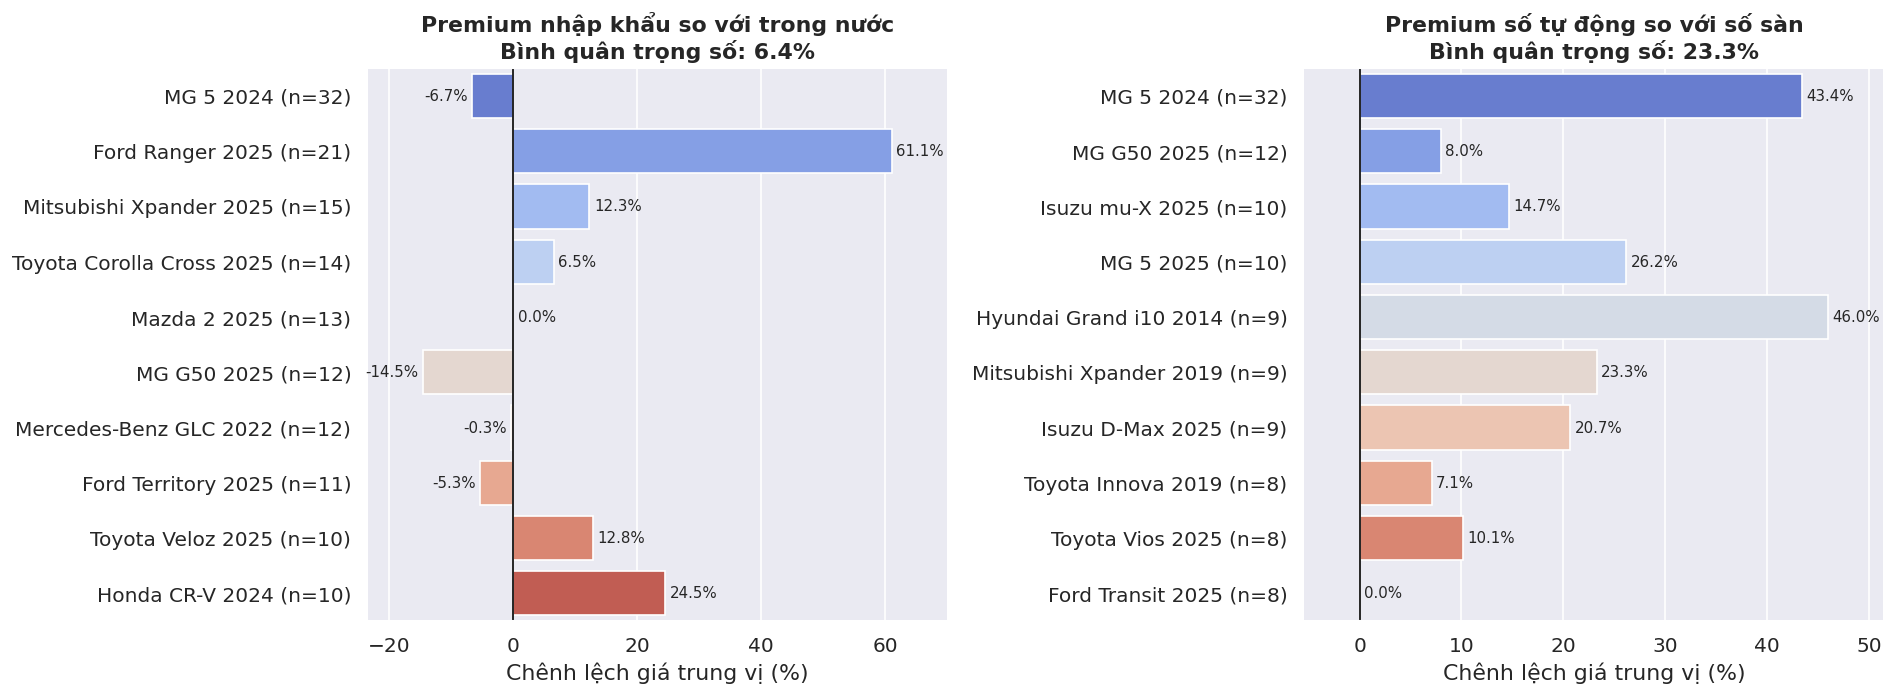

Insight: premium xe nhập khẩu bình quân trọng số là 6.4%, nhưng không phải dòng nào cũng cao hơn xe trong nước. Cần định giá theo từng dòng xe/đời xe, không áp một mức premium cố định cho toàn thị trường.
Số tự động đang có premium bình quân khoảng 23.3% so với số sàn trong các cặp đủ dữ liệu; đây là biến nên giữ trong mô hình định giá bán ra.
✓ Đã lưu → output/business_03_feature_premium.png


In [13]:
origin_premium = compute_feature_premium(
    df,
    feature_col='xuat_xu',
    premium_value='Nhập khẩu',
    base_value='Trong nước',
)
transmission_premium = compute_feature_premium(
    df,
    feature_col='hop_so',
    premium_value='Số tự động',
    base_value='Số sàn',
)

print('=== Cặp so sánh xuất xứ có nhiều mẫu nhất ===')
display(origin_premium.head(10).round({
    'premium_pct': 1,
    'premium_price_million': 0,
    'base_price_million': 0,
}))

print('=== Cặp so sánh hộp số có nhiều mẫu nhất ===')
display(transmission_premium.head(10).round({
    'premium_pct': 1,
    'premium_price_million': 0,
    'base_price_million': 0,
}))

plot_feature_premium(
    origin_premium,
    transmission_premium,
    OUTPUT_DIR / 'business_03_feature_premium.png',
)

origin_weighted = origin_premium.attrs.get('weighted_premium_pct', np.nan)
trans_weighted = transmission_premium.attrs.get('weighted_premium_pct', np.nan)
print(
    f"Insight: premium xe nhập khẩu bình quân trọng số là {origin_weighted:.1f}%, "
    'nhưng không phải dòng nào cũng cao hơn xe trong nước. Cần định giá theo từng dòng xe/đời xe, '
    'không áp một mức premium cố định cho toàn thị trường.'
)
print(
    f"Số tự động đang có premium bình quân khoảng {trans_weighted:.1f}% so với số sàn trong các cặp đủ dữ liệu; "
    'đây là biến nên giữ trong mô hình định giá bán ra.'
)
print('✓ Đã lưu → output/business_03_feature_premium.png')

## 11. Đóng kết nối

In [14]:
if db is not None:
    db.close()
    print('✓ Đã đóng kết nối DB')
else:
    print('✓ Notebook chạy bằng CSV backup, không có kết nối DB cần đóng')
print(f'\nTất cả biểu đồ đã lưu tại: {OUTPUT_DIR}')

[DB] Đã đóng kết nối MySQL.
✓ Đã đóng kết nối DB

Tất cả biểu đồ đã lưu tại: /Users/macbook/Documents/Car_Data_Analysis/output
